# AdaBoost Lab

This lab will walk you through the intuition and mechanics of AdaBoost. By the end, you will understand these learning objectives: 

1. What boosting is and why it works
2. How to implement the AdaBoost algorithm step-by-step, with code + math
3. How sample weights evolve across rounds
4. How weak learners combine into a strong ensemble learner


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier
from pathlib import Path

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

---
## Boosting

A single simple classifier (a "weak learner") may only be slightly better than random chance by itself (accuracy >50%). AdaBoost trains a sequence of them, making each one pay extra attention to the examples the previous ones got wrong. Combining them in the right way will give us a more powerful learner.

**AdaBoost** (Adaptive Boosting, Freund & Schapire 1997) makes this concrete:
- Each training example carries a **weight** $w_i$ (initially uniform).
- In each round $m$, we fit a decision stump $T_m$ to the weighted data.
- Misclassified examples get **higher weights** in the next round.
- $T_m$ is assigned a scalar **vote strength/amount of say** $\alpha_m$ based on its accuracy.
- The final classifier is $T(x) = \text{sign}\!\left(\sum_{m=1}^M \alpha_m\, T_m(x)\right)$.

---
## AdaBoost Algorithm 

Given training data $(x_1, y_1), \ldots, (x_N, y_N)$ with $y_i \in \{-1, +1\}$:

**Initialize:** $w_i = \frac{1}{N}$ for all $i$.

**For** $m = 1, 2, \ldots, M$:

1. Train a weak learner decision stump $T_m$ using weights $w$:

   
   `h = DecisionTreeClassifier(max_depth=1, random_state=0)`

   
   `h.fit(X, y, sample_weight=w)`

3. Compute the **weighted misclassification error rate**:
$$err_m = \dfrac{\sum_{i=1}^{N} w_i \cdot \mathbf{1}[T_m(x_i) \neq y_i]}{\sum_{i=1}^{N} w_i}$$

4. Compute the **amount of say** for this stump:
$$\alpha_m =  \ln\!\left(\frac{1 - err_m}{err_m}\right)$$

5. **Update sample weights** — increase weight for mistakes, keep constant for the correct ones:
$$w_i \leftarrow w_i \cdot \exp\!\left(\alpha_m \cdot \mathbf{1}[y_i \neq T_m(x_i)]\right)$$

> **Notice:** When $T_m(x_i) = y_i$ (correct), the exponent is $0$, so $w_i e^0 = w_i$ stays unchanged. But when $T_m(x_i) \neq y_i$ (wrong), the exponent is $\alpha_m > 0$, so $w_i$ increases to $w_ie^{\alpha_m}$. Misclassified examples therefore carry more influence in the next round.

**Final prediction:**
$$T(x) = \text{sign}\!\left(\sum_{m=1}^{M} \alpha_m\, T_m(x)\right)$$



### Understanding $\alpha_m$

Let's plot $\alpha_m$ as a function of the error $err_m$.

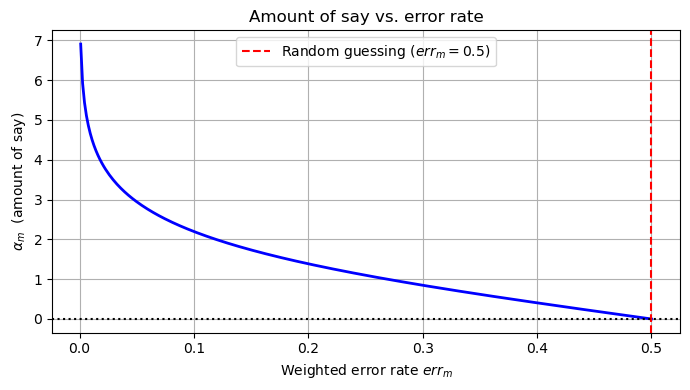

α_m when err=0.10: 2.197
α_m when err=0.25: 1.099
α_m when err=0.45: 0.201
α_m when err=0.5: 0.0


In [2]:
eps = np.linspace(0.001, 0.5, 300)
alpha = np.log((1 - eps) / eps)

plt.figure(figsize=(7, 4))
plt.plot(eps, alpha, 'b-', linewidth=2)
plt.axvline(0.5, color='r', linestyle='--', label='Random guessing ($err_m = 0.5$)')
plt.axhline(0,   color='k', linestyle=':')
plt.xlabel('Weighted error rate $err_m$')
plt.ylabel(r'$\alpha_m$  (amount of say)')
plt.title('Amount of say vs. error rate')
plt.legend()
plt.tight_layout()
plt.show()

print("α_m when err=0.10:", round(np.log(0.9/0.1), 3))
print("α_m when err=0.25:", round(np.log(0.75/0.25), 3))
print("α_m when err=0.45:", round(np.log(0.55/0.45), 3))
print("α_m when err=0.5:", round(np.log(0.5/0.5), 3))

**Observations:**
- The more accurate the weak learner (low $err_m$), the higher its amount of say $\alpha_m$.
- A random guesser ($err_m = 0.5$) gets $\alpha_m = 0$ — no say at all.
- AdaBoost only requires each weak learner to be slightly better than chance ($err_m < 0.5$).

---
## Tracing AdaBoost on a Toy 1D Example

Let's manually step through 3 rounds of AdaBoost on a tiny dataset with 8 points in 1D. 

In [3]:
# 8-point 1D dataset (positions and labels)
X1d = np.array([[1], [2], [3], [4], [5], [6], [7], [8]], dtype=float)
y1d = np.array([-1, -1, +1, +1, -1, -1, +1, +1])

N = len(y1d)
print("x :", X1d.flatten().astype(int))
print("y :", y1d)

x : [1 2 3 4 5 6 7 8]
y : [-1 -1  1  1 -1 -1  1  1]


In [4]:
def run_adaboost_trace(X, y, M=3):
    """Run AdaBoost for M rounds and print detailed trace."""
    N = len(y)
    w = np.ones(N) / N          # uniform 1/N initial weights
    trees, alphas = [], []

    for m in range(M):
        print(f"-")
        print(f"Round m = {m+1}")
        print(f"-")
        print(f"  Weights w  : {w}")

        # 1. train stump T_m
        h = DecisionTreeClassifier(max_depth=1, random_state=0)
        h.fit(X, y, sample_weight=w)
        pred = h.predict(X)
        print(f"  T_m preds  : {pred}")
        print(f"  Ground truth  : {y}")


        # 2. calc weighted error rate
        mistakes = (pred != y).astype(float)
        err_m = np.dot(w, mistakes) / np.sum(w)
        err_m = np.clip(err_m, 1e-12, 1 - 1e-12) #clip to avoid numerical issues of div by 0
        print(f"  Mistakes   : {mistakes}")
        print(f"  err_m   : {err_m:.4f}")
        print(f"  sum(w)     : {np.sum(w):.4f}")

        # 3. calc amount of say
        alpha =  np.log((1 - err_m) / err_m)
        print(f"  α_m        : {alpha:.4f}")

        # 4. increase weight for mistakes, keep correct ones constant
        w = w * np.exp(alpha * mistakes)

        trees.append(h)
        alphas.append(alpha)

    return trees, alphas

trees1d, alphas1d = run_adaboost_trace(X1d, y1d, M=3)

-
Round m = 1
-
  Weights w  : [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
  T_m preds  : [-1 -1  1  1  1  1  1  1]
  Ground truth  : [-1 -1  1  1 -1 -1  1  1]
  Mistakes   : [0. 0. 0. 0. 1. 1. 0. 0.]
  err_m   : 0.2500
  sum(w)     : 1.0000
  α_m        : 1.0986
-
Round m = 2
-
  Weights w  : [0.125 0.125 0.125 0.125 0.375 0.375 0.125 0.125]
  T_m preds  : [-1 -1 -1 -1 -1 -1  1  1]
  Ground truth  : [-1 -1  1  1 -1 -1  1  1]
  Mistakes   : [0. 0. 1. 1. 0. 0. 0. 0.]
  err_m   : 0.1667
  sum(w)     : 1.5000
  α_m        : 1.6094
-
Round m = 3
-
  Weights w  : [0.125 0.125 0.625 0.625 0.375 0.375 0.125 0.125]
  T_m preds  : [ 1  1  1  1 -1 -1 -1 -1]
  Ground truth  : [-1 -1  1  1 -1 -1  1  1]
  Mistakes   : [1. 1. 0. 0. 0. 0. 1. 1.]
  err_m   : 0.2000
  sum(w)     : 2.5000
  α_m        : 1.3863


**Notice how the weights shift:** 

After Round 1, only the examples $T_1$ got wrong receive higher $w_i$ — the correctly classified ones stay the same. Those misclassified examples then represent a larger share of the total weight, so $T_2$ pays more attention to them. Then $T_2$ makes new mistakes so they are treated as more important when training $T_3$.

## We still have to combine our stumps to get our boosting model:

In [5]:
# Final ensemble prediction: T(x) = sign( sum_m alpha_m * T_m(x) )
scores = sum(alpha_m * T_m.predict(X1d) for alpha_m, T_m in zip(alphas1d, trees1d))
final_preds = np.sign(scores)

print("Ensemble scores (raw):", np.round(scores, 3))
print("Final predictions    :", final_preds.astype(int))
print("True labels          :", y1d)
print("Accuracy             :", np.mean(final_preds == y1d))

Ensemble scores (raw): [-1.322 -1.322  0.875  0.875 -1.897 -1.897  1.322  1.322]
Final predictions    : [-1 -1  1  1 -1 -1  1  1]
True labels          : [-1 -1  1  1 -1 -1  1  1]
Accuracy             : 1.0


---
## Visualizing AdaBoost on 2D Data

We'll use a 2D synthetic dataset (two interleaved moons) and watch the decision boundary evolve as we add more rounds.

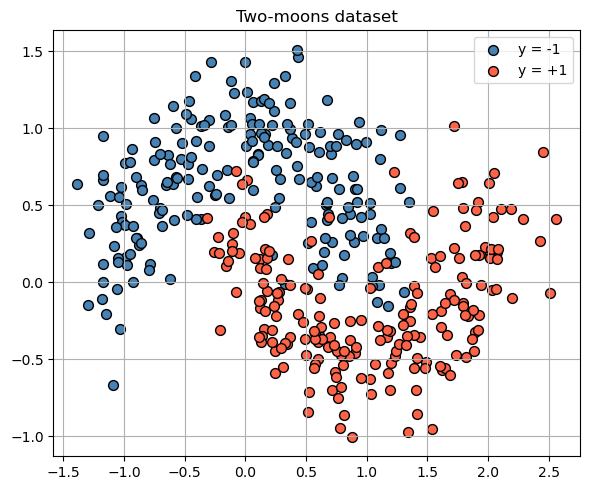

In [6]:
from sklearn.datasets import make_moons

X2d, y2d_raw = make_moons(n_samples=400, noise=0.25, random_state=7)
y2d = np.where(y2d_raw == 0, -1, +1)   # convert to {-1, +1}

plt.figure(figsize=(6, 5))
plt.scatter(X2d[y2d == -1, 0], X2d[y2d == -1, 1],
            c='steelblue', label='y = -1', edgecolors='k', s=50)
plt.scatter(X2d[y2d == +1, 0], X2d[y2d == +1, 1],
            c='tomato',   label='y = +1', edgecolors='k', s=50)
plt.title('Two-moons dataset')
plt.legend()
plt.tight_layout()
plt.show()

### Note on the weighted error rate 

In this lab we use the **weighted misclassification error rate**

$$err_m = \frac{\sum_i w_i\,\mathbf{1}[T_m(x_i) \neq y_i]}{\sum_i w_i}$$

This choice makes $$\alpha_m = \log\big(\dfrac{1-err_m}{err_m}\big)$$ invariant to multiplying all weights by a constant (i.e. only weight ratios matter).

We also use the update rule

$$
w_i \leftarrow w_i\,\exp\big(\alpha_m\,\mathbf{1}[T_m(x_i) \neq y_i]\big),
$$

which increases weights on misclassified points and leaves correctly-classified points unchanged.

**Implementation detail:** you may optionally rescale weights each round (e.g., `w = w / w.sum()`) to avoid numerical overflow. This does *not* change the learned stump (since only relative weights matter) or $err_m$ (because of the normalization by $\sum_i w_i$).


Helper functions for fitting adaboost and visualization:

In [7]:
def adaboost_reference(X, y, num_iter, max_depth=1):
    """For visualization."""
    trees, alphas = [], []
    N = len(y)
    w = np.ones(N) / N
    for _ in range(num_iter):
        h = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        h.fit(X, y, sample_weight=w)
        pred = h.predict(X)
        mistakes = (pred != y).astype(float)
        
        # Compute the weighted error rate 
        err_m = np.dot(w, mistakes) / np.sum(w)

        # Numerical guardrails (avoid inf/-inf if err_m hits 0 or 1 exactly)
        err_m = np.clip(err_m, 1e-12, 1 - 1e-12)

        alpha = np.log((1 - err_m) / err_m)

        # increase weights on misclassified points, leave others unchanged
        w = w * np.exp(alpha * mistakes)

        #w = w / np.sum(w) #optional renormalization
        trees.append(h)
        alphas.append(alpha)
    return trees, alphas

def adaboost_predict_reference(X, trees, alphas):
    scores = sum(alpha_m * T_m.predict(X) for alpha_m, T_m in zip(alphas, trees))
    return np.sign(scores)

def plot_boundary(X, y, trees, alphas, title):
    h = 0.04
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = adaboost_predict_reference(np.c_[xx.ravel(), yy.ravel()], trees, alphas)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='tomato',
                edgecolors='k', s=30, label='y = -1')
    plt.scatter(X[y == +1, 0], X[y == +1, 1], c='steelblue',
                edgecolors='k', s=30, label='y = +1')
    acc = np.mean(adaboost_predict_reference(X, trees, alphas) == y)
    plt.title(f"{title}  (train acc = {acc:.2%})")
    plt.legend(fontsize=8)
    plt.axis('off')

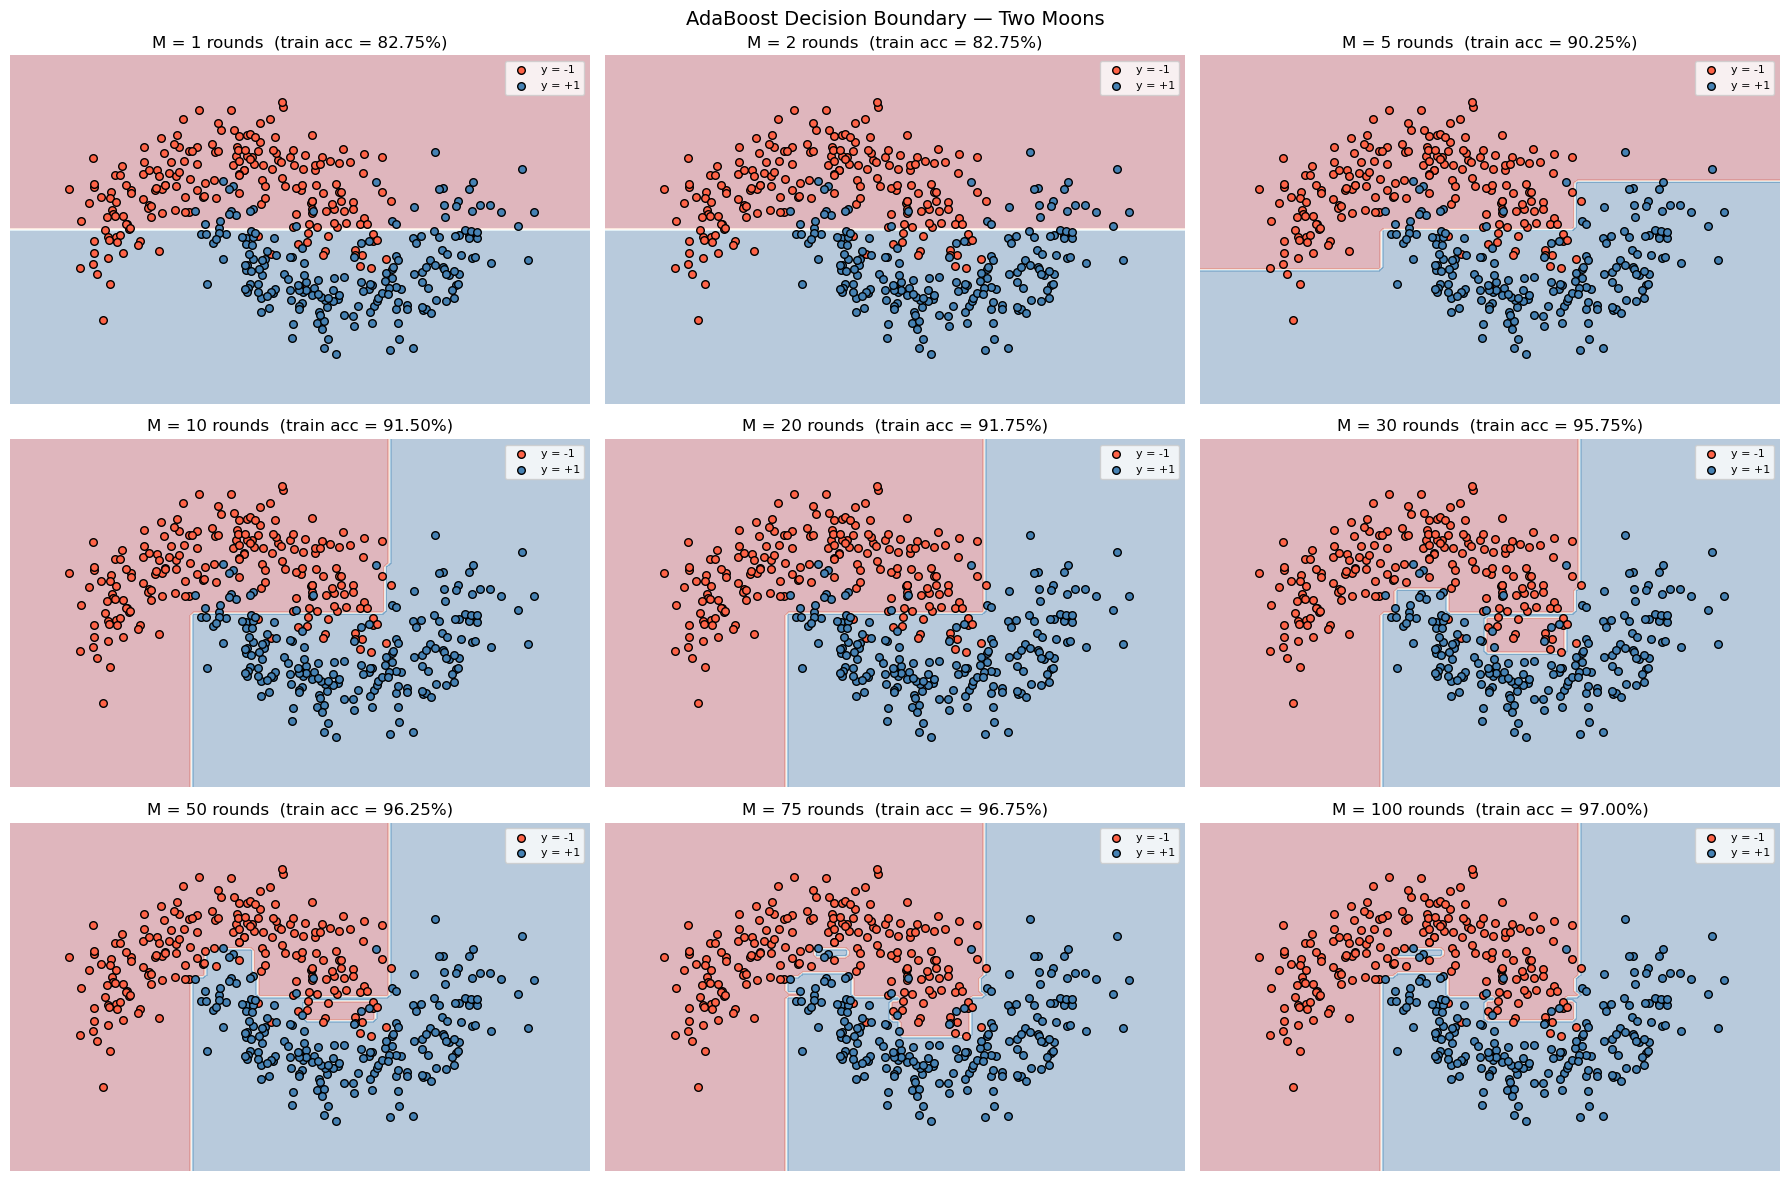

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

Ms = [1, 2, 5, 10, 20, 30, 50, 75, 100]

for ax, M in zip(axes.flatten(), Ms):
    plt.sca(ax)
    ts, alphas = adaboost_reference(X2d, y2d, M)
    plot_boundary(X2d, y2d, ts, alphas, f'M = {M} rounds')

plt.suptitle('AdaBoost Decision Boundary — Two Moons', fontsize=14)
plt.tight_layout()
plt.show()


**Observe:**
- With $M=1$ (a single stump), the boundary is one straight line.
- As $M$ grows, the boundary becomes more complex and accurate.
- AdaBoost is essentially building a **nonlinear** classifier out of linear weak learners.

---
## Weight evolution over time

Let's visualize how sample weights change over rounds. Large dots = high weight (the current stump focuses on these).

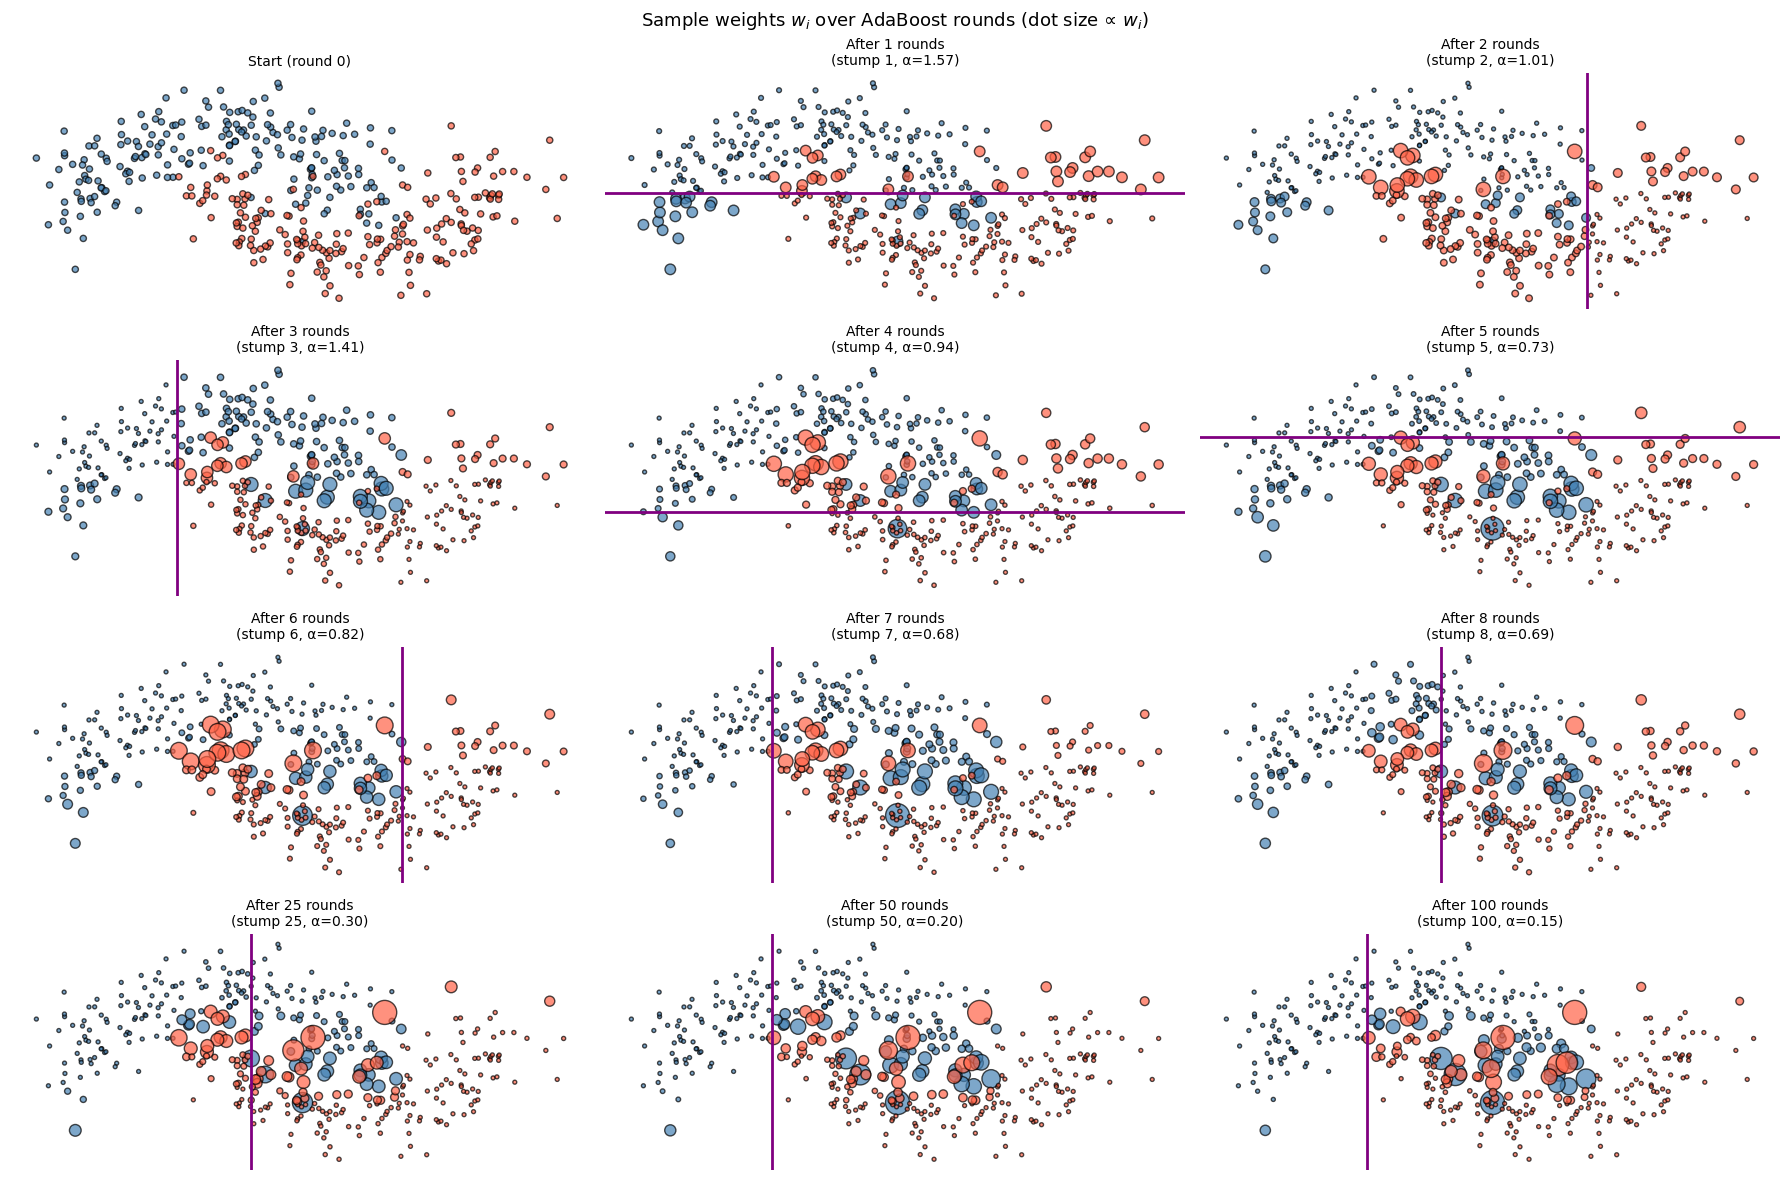

In [9]:
def adaboost_with_weight_history(X, y, num_iter, max_depth=1):
    """Same as reference but also records weights at each round."""
    trees, alphas, weight_history = [], [], []
    N = len(y)
    w = np.ones(N) / N
    weight_history.append(w.copy())
    for _ in range(num_iter):
        h = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        h.fit(X, y, sample_weight=w)
        pred = h.predict(X)
        mistakes = (pred != y).astype(float)
        err_m = np.dot(w, mistakes) / np.sum(w)
        err_m = np.clip(err_m, 1e-12, 1 - 1e-12)
        alpha = np.log((1 - err_m) / err_m)
        w = w * np.exp(alpha * mistakes)
        #w = w / np.sum(w) #optional normalization
        trees.append(h)
        alphas.append(alpha)
        weight_history.append(w.copy())
    return trees, alphas, weight_history

# Visualize weights at a wider range of rounds (dot size ∝ w_i)
rounds_to_show = [0, 1, 2, 3, 4,5,6,7,8,25,50,100]
max_round = max(rounds_to_show)

ts_full, alphas_full, wh = adaboost_with_weight_history(X2d, y2d, max_round)

fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, r in zip(axes, rounds_to_show):
    plt.sca(ax)

    # scale dot sizes by relative weight (stable across different N / normalization)
    rel = wh[r] / np.mean(wh[r])
    sizes = np.clip(20 * rel, 8, 300)

    plt.scatter(X2d[y2d == -1, 0], X2d[y2d == -1, 1],
                s=sizes[y2d == -1], c='steelblue', edgecolors='k', alpha=0.7)
    plt.scatter(X2d[y2d == +1, 0], X2d[y2d == +1, 1],
                s=sizes[y2d == +1], c='tomato', edgecolors='k', alpha=0.7)

    if r == 0:
        plt.title("Start (round 0)", fontsize=10)
    else:
        tree = ts_full[r - 1]
        feat = tree.tree_.feature[0]
        thresh = tree.tree_.threshold[0]
        if feat == 0:
            plt.axvline(thresh, color='purple', linewidth=2)
        else:
            plt.axhline(thresh, color='purple', linewidth=2)

        plt.title(f"After {r} rounds\n(stump {r}, α={alphas_full[r-1]:.2f})", fontsize=10)

    plt.axis('off')

plt.suptitle('Sample weights $w_i$ over AdaBoost rounds (dot size ∝ $w_i$)', fontsize=13)
plt.tight_layout()
plt.show()


The points with the largest size are the ones that have been most frequently misclassified by previous stumps!

## Exercise: 

---
## Spambase Dataset from HW5

The homework uses the *Spambase* dataset from UCI. Each email is described by 57 numerical features:
- 48 features: frequency of specific words (e.g., `word_freq_free`, `word_freq_money`)
- 6 features: frequency of specific characters (e.g., `char_freq_$`, `char_freq_!`)
- 3 features: statistics about sequences of capital letters

The label is `1` for spam, `0` for not-spam — **but AdaBoost requires labels in $\{-1, +1\}$**.

Your first task (`parse_spambase_data`) must handle this conversion.

In [10]:
# ── What does a raw line look like? ─────────────────────────────────────────
PATH = Path("data")

with open(PATH / "tiny.spam.train") as f:
    lines = f.readlines()

print(f"Number of lines (examples): {len(lines)}")
print("\nFirst line (raw):")
print(lines[0:3])   # first 3 rows

FileNotFoundError: [Errno 2] No such file or directory: 'data/tiny.spam.train'

In [ ]:
# ── Manually parsing one line ─────────────────────────────────────────────
row = [float(v) for v in lines[0].strip().split(',')]
print(f"Total values per row: {len(row)}")  # 57 features + 1 label
print(f"Label (raw):          {row[-1]}")   # 0 or 1, last value
print(f"Label (converted):    {-1 if row[-1] == 0 else +1}")
print(f"Features shape would be: (N, {len(row)-1})")

Total values per row: 58
Label (raw):          1.0
Label (converted):    1
Features shape would be: (N, 57)


### What `parse_spambase_data` must do

1. Read the file line-by-line (or use `np.loadtxt` / `np.genfromtxt`)
2. Split each row by comma and convert values to floats
3. The **last column**  is the label; everything else is a feature
4. Convert labels: `0 → -1`, `1 → +1` (AdaBoost assumes $y_i \in \{-1, +1\}$)
5. Return `X` of shape `(N, 57)` and `Y` of shape `(N,)`


---
## The `adaboost` Function

Here is the exact scaffold you must fill in, annotated with what each step should do.

In [ ]:
# ── Annotated scaffold  ──

def adaboost_annotated(X, y, num_iter, max_depth=1):
    trees = []
    trees_weights = []
    N, _ = X.shape

    # 1. Initialize uniform sample weights w_i = 1/N
    w = ...  # YOUR CODE

    for m in range(num_iter):

        # 2. Create and train weak learner T_m with current weights w
        #    Use DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        #    Pass w as sample_weight when calling .fit()
        h = ...  # YOUR CODE
        h.fit(...)  # YOUR CODE

        # 3. Get T_m's predictions on the training data
        pred = ...  # YOUR CODE

        # 4. Compute weighted error: err_m = (sum_i w_i * 1[T_m(x_i) != y_i]) / (sum_i w_i)
        #    Hint: (pred != y) gives a boolean array; cast to float
        #    Hint: np.dot is useful here
        err_m = ...  # YOUR CODE

        # 5. Compute amount of say: α_m = ln((1 - err_m) / err_m)
        #    Hint: use np.log (natural log)
        alpha = ...  # YOUR CODE

        # 6. Update sample weights: multiply misclassified by exp(α_m), keep correct ones constant
        #    w_i *= exp(α_m * 1[T_m(x_i) != y_i])
        #    Hint: reuse the mistakes indicator array from step ④
        w = w * np.exp(...)  # YOUR CODE

        # 7. Store the tree T_m and its amount of say α_m
        trees.append(h)
        trees_weights.append(alpha)

    return trees, trees_weights

---
## The `adaboost_predict` Function

Once you have trained your ensemble, prediction is a **weighted vote**:

$$T(x) = \text{sign}\!\left(\sum_{m=1}^{M} \alpha_m \cdot T_m(x)\right)$$

For each example:
- Each weak learner $T_m$ votes $+1$ or $-1$.
- The vote is scaled by $\alpha_m$ (more accurate learner = more say).
- Sum all weighted votes and take the sign.

In [ ]:
# ── Concrete illustration of the weighted sum ──────────────────────────────
# Suppose we have 3 weak learners with these α_m values:
demo_alphas = [1.2, 0.8, 0.5]

# And for one example x, their predictions T_m(x) are:
demo_preds = [+1, +1, -1]   # 2 vote +1, 1 votes -1

weighted_sum = sum(alpha_m * T_m for alpha_m, T_m in zip(demo_alphas, demo_preds))
final = np.sign(weighted_sum)

print("Weighted votes (α_m * T_m(x)):", [a*p for a,p in zip(demo_alphas, demo_preds)])
print("Sum                           :", weighted_sum)
print("T(x) = sign(sum)              :", int(final))

Weighted votes (α_m * T_m(x)): [1.2, 0.8, -0.5]
Sum                           : 1.5
T(x) = sign(sum)              : 1


In [ ]:
# ── Annotated scaffold ──────────────────────────────────────────────────────

def adaboost_predict_annotated(X, trees, trees_weights):
    N, _ = X.shape

    # 1. Start with a zero score for each example
    y = np.zeros(N)

    # 2. For each (T_m, α_m) pair:
    #      - call T_m.predict(X) to get predictions (+1 or -1) for all N examples
    #      - scale by α_m
    #      - sum cumulatively into y
    for T_m, alpha_m in zip(trees, trees_weights):
        y += ...  # YOUR CODE

    # 3. Return T(x) = sign(y) for each example
    return np.sign(y)

---
## Testing Your Implementation

Once you fill in `adaboost.py`, use these cells to verify correctness before running the autograder.

In [ ]:
# Uncomment after implementing adaboost.py
from adaboost import parse_spambase_data, adaboost, adaboost_predict, accuracy

In [ ]:
# ── Test 1: parse_spambase_data ─────────────────────────────────────────────
from adaboost import parse_spambase_data

X, Y = parse_spambase_data("data/tiny.spam.train")
y_expected = np.array([1., -1., 1., 1., -1., -1., 1., 1., 1., -1.])

assert np.array_equal(Y, y_expected), f"Y mismatch: {Y}"
assert X.shape == (10, 57), f"X shape wrong: {X.shape}"
print("parse_spambase_data: PASSED")

parse_spambase_data: PASSED


In [ ]:
# ── Test 2: adaboost ────────────────────────────────────────────────────────
X, Y = parse_spambase_data("data/tiny.spam.train")
trees, weights = adaboost(X, Y, 2)

assert len(trees) == 2
assert len(weights) == 2
assert isinstance(trees[0], DecisionTreeClassifier)

y_hat_0 = trees[0].predict(X)
y_hat_true = np.array([ 1., -1., 1., 1., -1., -1., -1., 1., 1., -1.])
assert np.array_equal(y_hat_0, y_hat_true), f"Round-1 predictions wrong: {y_hat_0}"
print("adaboost: PASSED")

adaboost: PASSED


In [ ]:
# ── Test 3: adaboost_predict ────────────────────────────────────────────────
x = np.array([[0, -1], [1, 0], [-1, 0]])
y = np.array([-1, 1, 1])
trees, weights = adaboost(x, y, 1)
pred = adaboost_predict(x, trees, weights)
assert np.array_equal(pred, y), f"Predictions wrong: {pred}"
print("adaboost_predict: PASSED")

adaboost_predict: PASSED


In [ ]:
# ── Test 4: Full spambase accuracy ─────────────────────────────────────────
X_tr, Y_tr = parse_spambase_data("data/spambase.train")
X_te, Y_te = parse_spambase_data("data/spambase.test")

trees, weights = adaboost(X_tr, Y_tr, 10)
acc_train = accuracy(Y_tr, adaboost_predict(X_tr, trees, weights))
acc_test  = accuracy(Y_te, adaboost_predict(X_te, trees, weights))

print(f"Train accuracy: {acc_train:.4f}  (expected ~0.9111)")
print(f"Test  accuracy: {acc_test:.4f}  (expected ~0.9190)")

assert np.around(acc_train, 4) == 0.9111
assert np.around(acc_test,  4) == 0.9190
print("Full accuracy check: PASSED")

Train accuracy: 0.9111  (expected ~0.9111)
Test  accuracy: 0.9190  (expected ~0.9190)
Full accuracy check: PASSED


---
## Considering Overfitting: Accuracy vs. Number of Rounds $M$

If we make $M$ too large, we run the risk of overfitting:


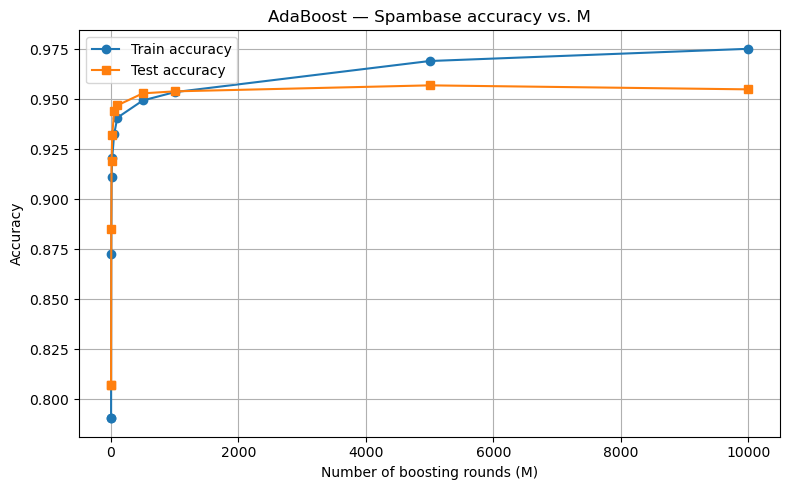

In [ ]:
# # Uncomment after implementing adaboost.py

X_tr, Y_tr = parse_spambase_data("data/spambase.train")
X_te, Y_te = parse_spambase_data("data/spambase.test")

M_values = [1, 2, 5, 10, 20, 50, 100, 500, 1000, 5000, 10000]
train_accs, test_accs = [], []

for M in M_values:
    ts, ws = adaboost(X_tr, Y_tr, M)
    train_accs.append(accuracy(Y_tr, adaboost_predict(X_tr, ts, ws)))
    test_accs.append(accuracy(Y_te, adaboost_predict(X_te, ts, ws)))

plt.figure(figsize=(8, 5))
plt.plot(M_values, train_accs, 'o-', label='Train accuracy')
plt.plot(M_values, test_accs,  's-', label='Test accuracy')
plt.xlabel('Number of boosting rounds (M)')
plt.ylabel('Accuracy')
plt.title('AdaBoost — Spambase accuracy vs. M')
plt.legend()
plt.tight_layout()
plt.show()

---
## Summary 

| Component | Formula / Code |
|---|---|
| Initial weights | `w = np.ones(N) / N` |
| Train weak learner $T_m$ | `h.fit(X, y, sample_weight=w)` |
| Weighted error rate $err_m$ | `err_m = np.dot(w, (pred != y).astype(float)) / np.sum(w)` |
| Amount of say $\alpha_m$ | `alpha = np.log((1 - err_m) / err_m)` |
| Weight update | `w = w * np.exp(alpha * (pred != y).astype(float))` |
| Final prediction $T(x)$ | `np.sign(sum(alpha_m * T_m.predict(X) for alpha_m, T_m in zip(alphas, trees)))` |

**Weight update intuition:** Misclassified points get multiplied by $e^{\alpha_m} > 1$ (weight goes up). Correctly classified points are multiplied by $e^0 = 1$ (weight stays the same). Misclassified examples therefore carry more influence in the next round.

**Label convention:** AdaBoost needs $y_i \in \{-1, +1\}$.  
The spambase labels are $\{0, 1\}$ — convert `0 → -1` in `parse_spambase_data`.
